---
title: "Functions, Loops, and Training the Network"
description: ""
subtitle: "5: Forward and Predict Functions"
engine: Jupyter
#jupyter: pytorch
title-block-banner: true
freeze: auto

execute:
    eval: true

author:
  - name: "Dr. Atle E. Rimehaug"

format:
  html: default
  ipynb: default
format-links: false
---

## Setup

### Import Libraries

In [13]:
import torch
from torch import nn
from pathlib import Path
import numpy as np

from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt

### Utility Functions

In [84]:
torch.argmax(output, 1)

tensor([0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
        0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
        1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
        1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
        1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
        1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1])

In [85]:
# Code adapted from this notebook: https://jonchar.net/notebooks/Artificial-Neural-Network-with-Keras/

def plot_decision_boundary(model: nn.Module, X: torch.Tensor, y: torch.Tensor, output: torch.Tensor, device: str):
    """
    Helper function to plot decision boundary

    Args:
    model: model instance
    X: Input data
    y: Class Labels/Targets
    device: "cpu" or "cuda"

    Returns:
    Nothing
    """
    # Transfer the data to the CPU
    X = X.cpu().numpy()
    y = y.cpu().numpy()

    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points = torch.from_numpy(grid_points).type(torch.FloatTensor)
    grid_output = model(grid_points)
    Z = torch.argmax(grid_output, 1)
    Z_grid = Z.reshape(xx.shape)

    # Plot the contour and training examples
    plt.contourf(xx, yy, Z_grid, cmap=plt.cm.Spectral)
    mask = torch.argmax(output, 1) == 0
    plt.plot(X[:,0][mask], X[:,1][mask], 'o', color = 'white', label = 'Label = 0')
    plt.plot(X[:,0][~mask], X[:,1][~mask], 'o', color = 'k', label = 'Label = 1')
    plt.legend()
    #plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.binary)

class utils:
    plot_decision_boundary = plot_decision_boundary

torch.Size([130210])

In [53]:
X = X_orig
y = y_orig

# Set min and max values and give it some padding
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
h = 0.01

# Generate a grid of points with distance h between them
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict the function value for the whole grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_points = torch.from_numpy(grid_points).type(torch.FloatTensor)
output = net(grid_points)
Z = torch.argmax(output, 1)
Z_grid = Z.reshape(xx.shape)

In [57]:
output.shape

torch.Size([130210, 2])

### Generate Data

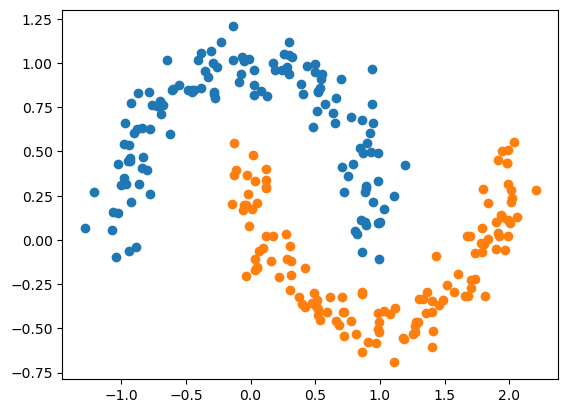

In [41]:
X_orig, y_orig = make_moons(256, noise=0.1)

'''df = pd.DataFrame({'x0': X[:, 0], 'x1': X[:,1], 'y': y})
# Create 2D numpy array from x0 and x1 columns
X_orig = df[['x0', 'x1']].to_numpy()

# Create a 1D numpy array from the y column
y_orig = df['y'].to_numpy()'''

mask = y_orig == 0
plt.plot(X_orig[:,0][mask], X_orig[:,1][mask], 'o', label = 'Label = 0')
plt.plot(X_orig[:,0][~mask], X_orig[:,1][~mask], 'o', label = 'Label = 1')

In [16]:
# Convert the 2D points to a tensor
X = torch.tensor(X_orig, dtype = torch.float32)

# Convert labels to long integer tensor
y = torch.from_numpy(y_orig).type(torch.LongTensor)

## Section 1: Functions and For Loops

| Code | Description |
| --- | --- |
| `for letter in ["a", "b", "c"]:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(letter)` | Print every `letter` in the list `["a", "b", "c"]`|
| `for i in range(5):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 0 and 5 (not including 5)|
| `for i in range(2, 7):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every number `i` between 2 and 7 (not including 7)|
| `for i in range(1, 10, 2):` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(i)` | Print every **second** number `i` between 1 and 10 (not including 10)|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `print(x_i)` | Print every element `x_i` in the collection `x`|
| `for x_i in x:` <br> &nbsp;&nbsp;&nbsp;&nbsp; `for y_i in y`: <br> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; `print(x_i, y_i)` | Print every element `x_i` and `y_i` in the collections `x` and `y`|
| `new_list = []` or `new_list = list()`| Initialize an empty list named `new_list` |
| `new_list.append(element)`| Append an element to the list `new_list` |

::: {#exm-}
Create a function named `add` that takes in two variables `a` and `b` and returns their sum.
:::

In [17]:
def fun(a, b):
    output = a + b
    return output

::: {#exr-}
Create a function named `subtract` that takes in two variables `a` and `b` and subtracts b from a. The function should return the result.
:::

In [18]:
def subtract(a, b):
    output = a - b
    return output

::: {#exr-}
Write a for loop that prints the numbers **0** to **9**.
:::

::: {#sol-}
:::

In [19]:
for num in range(9):
    print(num)

0
1
2
3
4
5
6
7
8


::: {#exr-}
Write a for loop that prints the numbers **5** to **10**.
:::

::: {#sol-}
:::

In [20]:
for i in range(5,10):
    print(i)

5
6
7
8
9


::: {#exr-}
Write a for loop that counts from **0** to **100** in steps of **10**.
:::

::: {#sol-}
:::

In [21]:
for j in range(0,100,10):
    print(j)

0
10
20
30
40
50
60
70
80
90


::: {#exr-}
Use a loop to print all `fruits` and `colors`, for example `banana is yellow"`.
:::

::: {#sol-}
:::

In [22]:
fruits = ["banana", "orange", "cherry"]
colors= ["yellow", "orange", "green"];

for fruit in fruits:
    for color in colors:
        print(fruit+' is '+color)

banana is yellow
banana is orange
banana is green
orange is yellow
orange is orange
orange is green
cherry is yellow
cherry is orange
cherry is green


::: {#exm-}
Write a loop that calculates the square of each element in `numbers` and stores the result in a new list called `squared_numbers`. Display the `squared_numbers` list at the end to check that it is correct.
:::

In [23]:
numbers = [4, 6, 12, 50]

squared_numbers = []

for i in range(len(numbers)):
    num_squared = numbers[i]**2
    squared_numbers.append(num_squared)

squared_numbers

[16, 36, 144, 2500]

::: {#exr-}
Write a loop that multiplies each element in the list `numbers` by 4 and store the results in a new list called `multiplied_numbers`. Display `multiplied_numbers` to check that it is correct.
:::

::: {#sol-}
:::

In [24]:
numbers = [4, 6, 12, 50]

multiplied_numbers = []
for num in numbers:
    mult_number = 4*num

    multiplied_numbers.append(mult_number)

multiplied_numbers

[16, 24, 48, 200]

## Section 2: Train the Network

| Code | Description |
| --- | --- |
| `def sum_input(a,b)` <br> &nbsp;&nbsp;&nbsp;&nbsp; `output = a+b` <br> &nbsp;&nbsp;&nbsp;&nbsp;  `return output` | Creates a function `sum_input` that takes two variables `a` and `b` as input and returns the sum of them. |

In [ ]:
# Convert the 2D points to a tensor
X = torch.tensor(X_orig, dtype = torch.float32)

# Convert labels to long integer tensor
y = torch.from_numpy(y_orig).type(torch.LongTensor)

In [90]:
net = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,2)
)

# select subset of data
X_samples = torch.tensor(X_orig, dtype=torch.float32)
y_samples = torch.from_numpy(y_orig).type(torch.LongTensor)

optimizer = torch.optim.Adam(net.parameters(), lr=0.01)

loss_function = nn.CrossEntropyLoss()

Epoch 0 loss is 0.7473005056381226
Epoch 100 loss is 0.14964742958545685
Epoch 200 loss is 0.03620089963078499
Epoch 300 loss is 0.014855326153337955
Epoch 400 loss is 0.008341037668287754
Epoch 500 loss is 0.00542084313929081
Epoch 600 loss is 0.0038292836397886276
Epoch 700 loss is 0.002852767240256071
Epoch 800 loss is 0.002210486214607954
Epoch 900 loss is 0.0017638973658904433


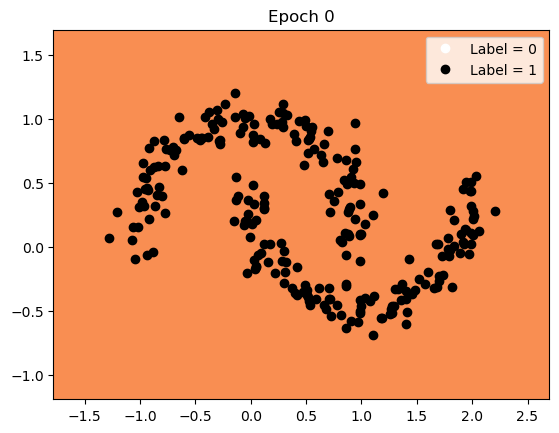

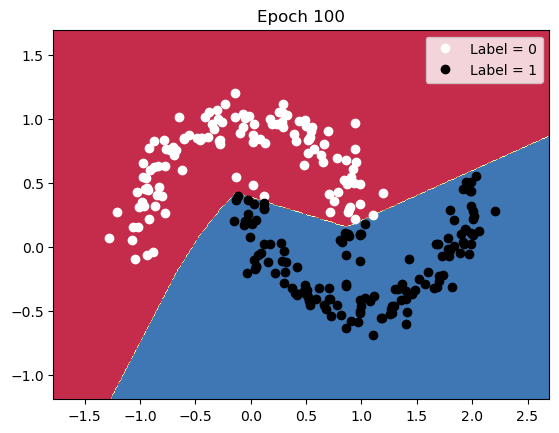

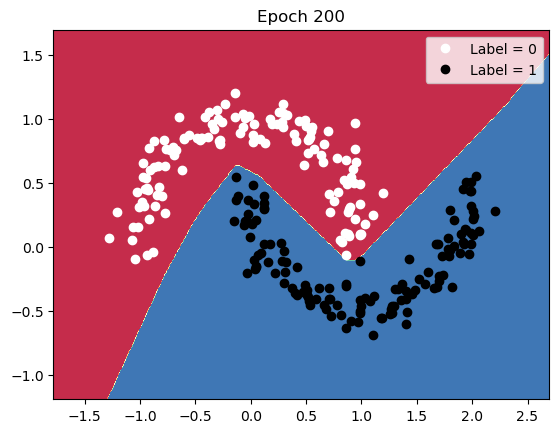

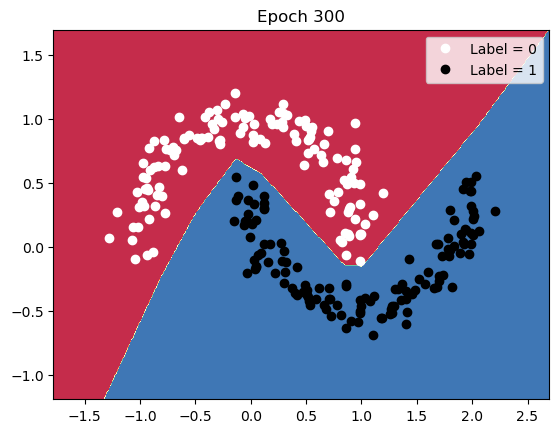

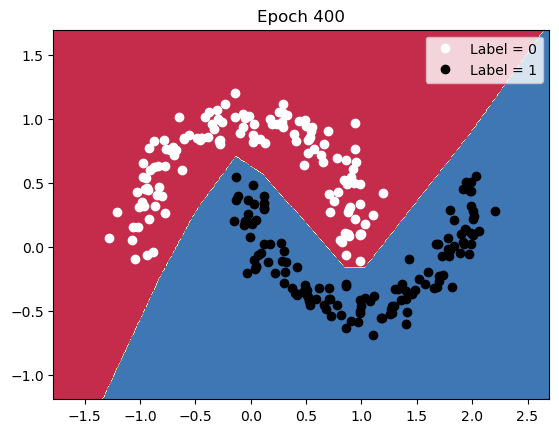

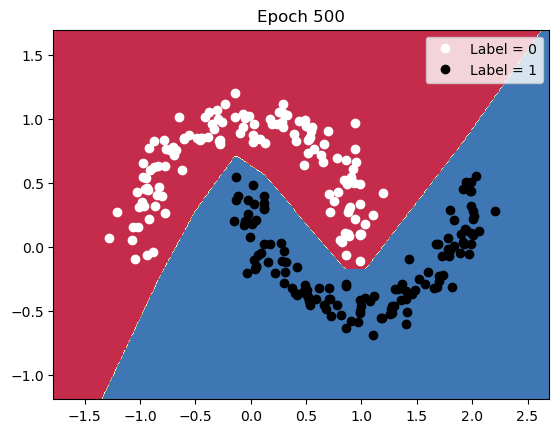

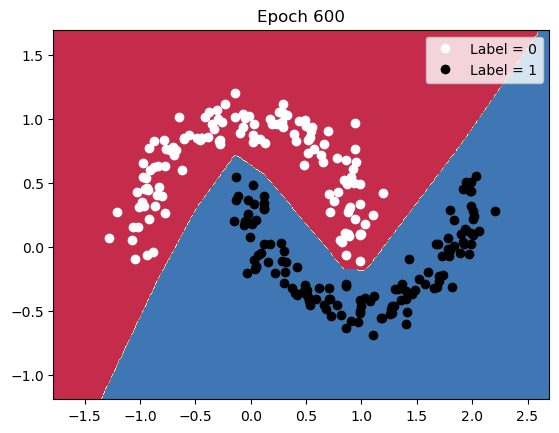

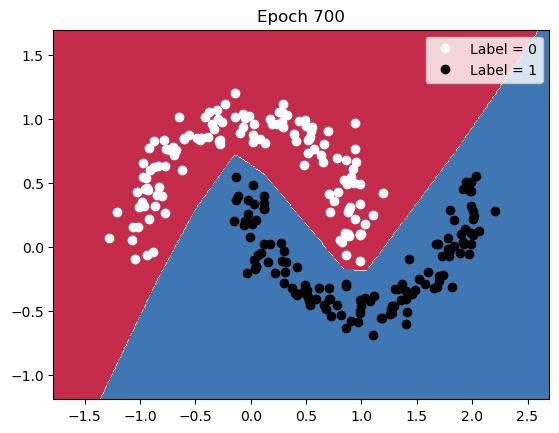

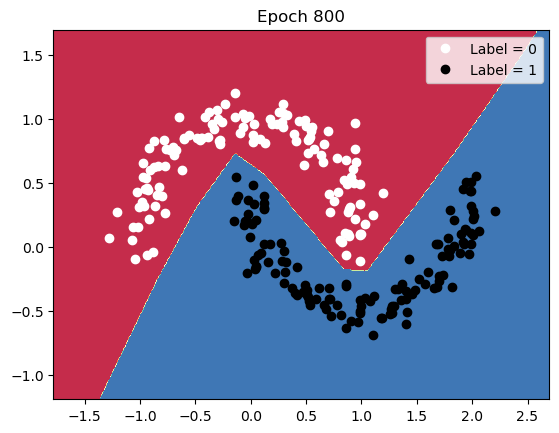

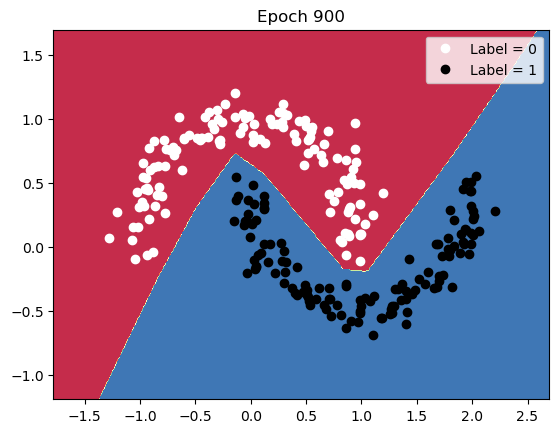

In [91]:
train_losses = []
num_epochs = 1000

for epoch in range(num_epochs):
    optimizer.zero_grad()

    output = net(X_samples)

    loss = loss_function(output, y_samples)

    train_losses.append(loss.item())

    loss.backward()

    optimizer.step()

    if epoch % 100 == 0:
      print(f"Epoch {epoch} loss is {loss.item()}")
      plt.figure()
      plt.title(f"Epoch {epoch}")
      utils.plot_decision_boundary(net, X_samples, y_samples, output, 'cpu')

In [ ]:
torch.output

torch.Size([256, 2])

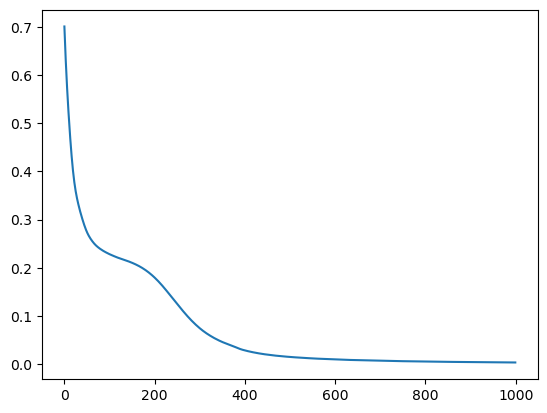

In [36]:
plt.plot(train_losses)

In [72]:
net

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)

IndexError: boolean index did not match indexed array along axis 0; size of axis is 256 but size of corresponding boolean axis is 125280

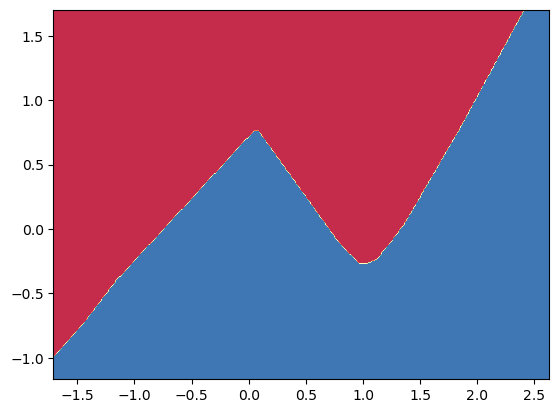

In [50]:
utils.plot_decision_boundary(net, X, y, 'cpu')